In [1]:
# Install kagglehub
!pip install kagglehub

# Imports
import kagglehub
import pandas as pd
import os

# Download IMDB dataset
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Dataset path:", path)

# List files
files = os.listdir(path)
print("Files:", files)

# Load dataset
file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

# Preview
print("\nSample Data:")
print(df.head())

print("\nDataset Info:")
print(df.info())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset path: /kaggle/input/imdb-dataset-of-50k-movie-reviews
Files: ['IMDB Dataset.csv']

Sample Data:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [2]:
import re

# 1. Remove HTML tags
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters
    text = text.lower().strip()  # lowercase + remove spaces
    return text

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

# 2. Convert sentiment labels to numeric
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Display updated dataset
print(df[['review', 'clean_review', 'sentiment', 'label']].head())

# Check if any nulls created
print("\nNull values check:")
print(df.isnull().sum())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review sentiment  label  
0  one of the other reviewers has mentioned that ...  positive      1  
1  a wonderful little production the filming tech...  positive      1  
2  i thought this was a wonderful way to spend ti...  positive      1  
3  basically theres a family where a little boy j...  negative      0  
4  petter matteis love in the time of money is a ...  positive      1  

Null values check:
review          0
sentiment       0
clean_review    0
label           0
dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

# Step 1: Train + Temp split (80% train, 20% temp)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['clean_review'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Step 2: Split temp into validation + test (10% each)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

# Print sizes
print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 40000
Validation size: 5000
Test size: 5000


In [4]:
from transformers import AutoTokenizer

# Load BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize datasets
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

# Check one example
print("Sample input_ids:", train_encodings['input_ids'][0][:20])
print("Sample attention_mask:", train_encodings['attention_mask'][0][:20])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample input_ids: [101, 1045, 3236, 2023, 2210, 17070, 6135, 2011, 4926, 2067, 1999, 2030, 1045, 2001, 2012, 1037, 6308, 3004, 2000, 2156]
Sample attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [5]:
import torch

class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

# Check one sample
print(train_dataset[0])

{'input_ids': tensor([  101,  1045,  3236,  2023,  2210, 17070,  6135,  2011,  4926,  2067,
         1999,  2030,  1045,  2001,  2012,  1037,  6308,  3004,  2000,  2156,
         2048,  2214, 10021, 16596,  8873,  5691,  1996,  3004,  2001,  8966,
         2440,  1998,  2007,  2053,  5432,  2027,  3662,  1037,  9129,  1997,
        16596,  8873,  2460, 11867, 21511,  2015,  2000,  2131,  2149,  1999,
         1996,  6888,  2087,  2020,  5399, 19142,  2021,  2023,  2234,  2006,
         1998,  2306,  3823,  1996,  4378,  2001,  1999,  1044, 27268, 22420,
         2015,  1996,  5221,  4756,  2234,  2043,  2027,  3662,  4615, 21110,
         2050,  2383,  4121, 21229, 21122,  2015,  2612,  1997,  2606,  2006,
         2014,  2132,  2016,  3504,  2012,  1996,  4950,  3957,  1037, 11844,
         2868,  1998, 11232,  2008,  2081,  2009,  2130,  4569, 14862,  2017,
        10657,  2156, 21271, 19736, 16665,  2209,  2011,  2054,  3504,  2066,
         1037, 14163, 29519,  2009,  2001,  5186, 

In [6]:
from transformers import AutoModelForSequenceClassification

# Load pre-trained BERT model
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2  # binary classification
)

# Move model to GPU if available
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [10]:
from torch.utils.data import DataLoader
import torch

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Define optimizer using PyTorch's native AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

print("DataLoaders and optimizer ready")

DataLoaders and optimizer ready


In [11]:
from tqdm import tqdm

model.train()

epochs = 1  # keep 1 for now (we can increase later)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}")

    total_loss = 0

    for batch in tqdm(train_loader):
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(**batch)

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    print("Average Training Loss:", avg_loss)


Epoch 1


100%|██████████| 2500/2500 [30:02<00:00,  1.39it/s]

Average Training Loss: 0.2549477199781686


In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np

model.eval()  # turn OFF dropout

all_preds = []
all_labels = []

with torch.no_grad():  # no gradients needed
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
conf_matrix = confusion_matrix(all_labels, all_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:\n", conf_matrix)

Accuracy: 0.9238
Precision: 0.9140289175459164
Recall: 0.9356
F1 Score: 0.9246886736509191

Confusion Matrix:
 [[2280  220]
 [ 161 2339]]


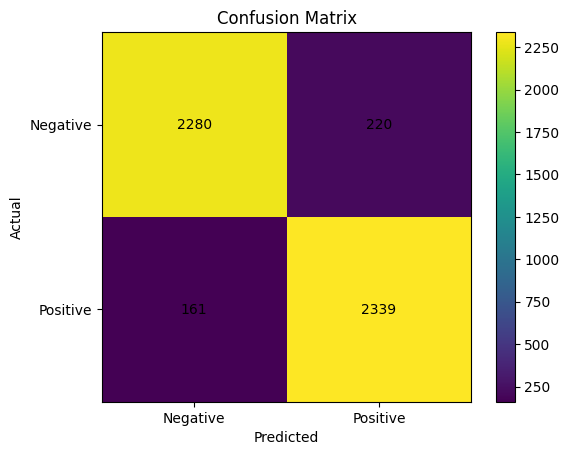

In [13]:
import matplotlib.pyplot as plt
import numpy as np

cm = conf_matrix

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

labels = ["Negative", "Positive"]
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
# Freeze all BERT layers
for param in model.bert.parameters():
    param.requires_grad = False

# Check (optional sanity)
print("BERT frozen. Trainable params:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

BERT frozen. Trainable params:
classifier.weight
classifier.bias


In [15]:
# Only optimize trainable parameters (classifier)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5
)

print("Optimizer reset for frozen model")

Optimizer reset for frozen model


In [16]:
from tqdm import tqdm

model.train()

epochs = 1

for epoch in range(epochs):
    print(f"\n[Experiment 1] Epoch {epoch+1}")

    total_loss = 0

    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    print("Average Training Loss:", avg_loss)


[Experiment 1] Epoch 1


100%|██████████| 2500/2500 [09:49<00:00,  4.24it/s]

Average Training Loss: 0.1236791345231235


In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
conf_matrix = confusion_matrix(all_labels, all_preds)

print("\n--- Experiment 1 Results (Frozen BERT) ---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:\n", conf_matrix)


--- Experiment 1 Results (Frozen BERT) ---
Accuracy: 0.9244
Precision: 0.91284046692607
Recall: 0.9384
F1 Score: 0.9254437869822485

Confusion Matrix:
 [[2276  224]
 [ 154 2346]]


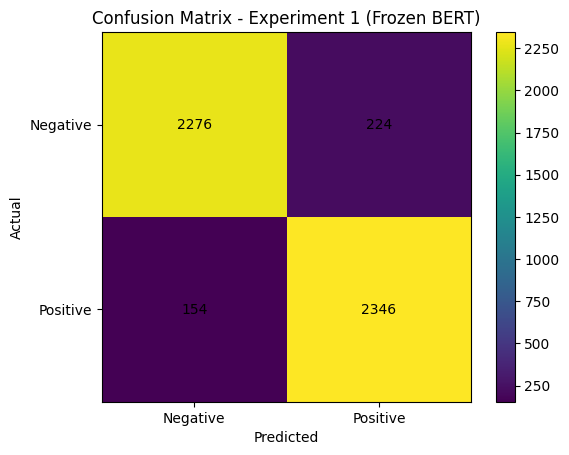

In [18]:
import matplotlib.pyplot as plt
import numpy as np

cm = conf_matrix  # from Experiment 1

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix - Experiment 1 (Frozen BERT)")
plt.colorbar()

labels = ["Negative", "Positive"]
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# First, freeze everything
for param in model.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 encoder layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

# Also ensure classifier is trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Verify trainable parameters
print("Trainable parameters in Experiment 2:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

# Reset optimizer for new trainable params
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5
)

print("\nOptimizer set for Experiment 2")

Trainable parameters in Experiment 2:
bert.encoder.layer.10.attention.self.query.weight
bert.encoder.layer.10.attention.self.query.bias
bert.encoder.layer.10.attention.self.key.weight
bert.encoder.layer.10.attention.self.key.bias
bert.encoder.layer.10.attention.self.value.weight
bert.encoder.layer.10.attention.self.value.bias
bert.encoder.layer.10.attention.output.dense.weight
bert.encoder.layer.10.attention.output.dense.bias
bert.encoder.layer.10.attention.output.LayerNorm.weight
bert.encoder.layer.10.attention.output.LayerNorm.bias
bert.encoder.layer.10.intermediate.dense.weight
bert.encoder.layer.10.intermediate.dense.bias
bert.encoder.layer.10.output.dense.weight
bert.encoder.layer.10.output.dense.bias
bert.encoder.layer.10.output.LayerNorm.weight
bert.encoder.layer.10.output.LayerNorm.bias
bert.encoder.layer.11.attention.self.query.weight
bert.encoder.layer.11.attention.self.query.bias
bert.encoder.layer.11.attention.self.key.weight
bert.encoder.layer.11.attention.self.key.bias
be

In [20]:
from tqdm import tqdm

model.train()

epochs = 1  # keep consistent with previous experiments

for epoch in range(epochs):
    print(f"\n[Experiment 2] Epoch {epoch+1}")

    total_loss = 0

    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    print("Average Training Loss:", avg_loss)


[Experiment 2] Epoch 1


100%|██████████| 2500/2500 [12:45<00:00,  3.27it/s]

Average Training Loss: 0.11663358483766205



--- Experiment 2 Results (Last 2 Layers Fine-Tuned) ---
Accuracy: 0.9248
Precision: 0.9125874125874126
Recall: 0.9396
F1 Score: 0.925896728419393

Confusion Matrix:
 [[2275  225]
 [ 151 2349]]


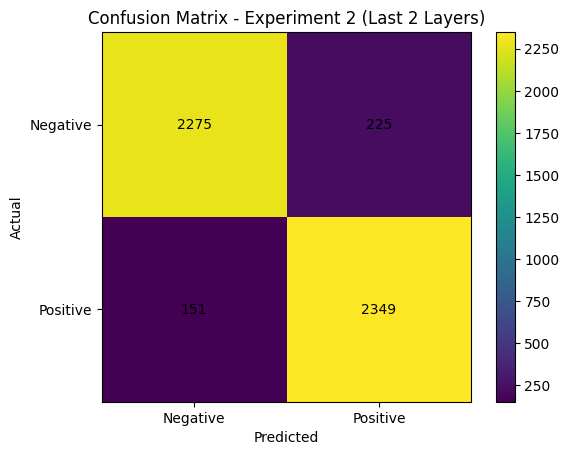

In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
conf_matrix = confusion_matrix(all_labels, all_preds)

print("\n--- Experiment 2 Results (Last 2 Layers Fine-Tuned) ---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:\n", conf_matrix)

# Heatmap Visualization
plt.figure()
plt.imshow(conf_matrix)

plt.title("Confusion Matrix - Experiment 2 (Last 2 Layers)")
plt.colorbar()

labels = ["Negative", "Positive"]
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

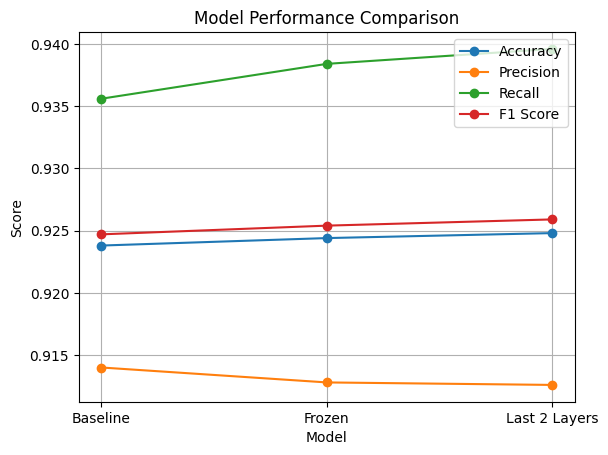

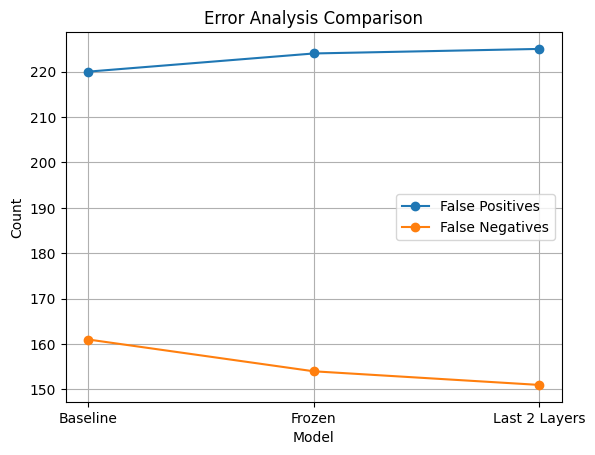

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
results = {
    "Model": ["Baseline", "Frozen", "Last 2 Layers"],
    "Accuracy": [0.9238, 0.9244, 0.9248],
    "Precision": [0.9140, 0.9128, 0.9126],
    "Recall": [0.9356, 0.9384, 0.9396],
    "F1 Score": [0.9247, 0.9254, 0.9259],
    "False Positives": [220, 224, 225],
    "False Negatives": [161, 154, 151]
}

df = pd.DataFrame(results)

# --- Plot 1: Core Metrics ---
plt.figure()
for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    plt.plot(df["Model"], df[metric], marker='o', label=metric)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

# --- Plot 2: Error Comparison ---
plt.figure()
x = range(len(df["Model"]))

plt.plot(x, df["False Positives"], marker='o', label="False Positives")
plt.plot(x, df["False Negatives"], marker='o', label="False Negatives")

plt.xticks(x, df["Model"])
plt.title("Error Analysis Comparison")
plt.xlabel("Model")
plt.ylabel("Count")
plt.legend()
plt.grid()
plt.show()

In [24]:
from transformers import AutoTokenizer

# Load RoBERTa tokenizer
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Tokenize datasets
train_encodings_roberta = roberta_tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings_roberta = roberta_tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings_roberta = roberta_tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

print("RoBERTa tokenization complete")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa tokenization complete


In [25]:
# Reuse same dataset class
train_dataset_roberta = IMDbDataset(train_encodings_roberta, train_labels)
val_dataset_roberta = IMDbDataset(val_encodings_roberta, val_labels)
test_dataset_roberta = IMDbDataset(test_encodings_roberta, test_labels)

print("RoBERTa datasets ready")

RoBERTa datasets ready


In [26]:
from transformers import AutoModelForSequenceClassification

# Load RoBERTa model
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

# Move to device
roberta_model.to(device)

print("RoBERTa model loaded on:", device)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa model loaded on: cuda


In [27]:
from torch.utils.data import DataLoader

train_loader_roberta = DataLoader(train_dataset_roberta, batch_size=16, shuffle=True)
val_loader_roberta = DataLoader(val_dataset_roberta, batch_size=16)

optimizer_roberta = torch.optim.AdamW(roberta_model.parameters(), lr=2e-5)

print("RoBERTa loaders and optimizer ready")

RoBERTa loaders and optimizer ready


In [28]:
from tqdm import tqdm

roberta_model.train()

epochs = 1

for epoch in range(epochs):
    print(f"\n[RoBERTa] Epoch {epoch+1}")

    total_loss = 0

    for batch in tqdm(train_loader_roberta):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer_roberta.zero_grad()

        outputs = roberta_model(**batch)
        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()
        optimizer_roberta.step()

    avg_loss = total_loss / len(train_loader_roberta)
    print("Average Training Loss:", avg_loss)


[RoBERTa] Epoch 1


100%|██████████| 2500/2500 [30:16<00:00,  1.38it/s]

Average Training Loss: 0.2234068070512265



--- RoBERTa Results ---
Accuracy: 0.9318
Precision: 0.9234994115339349
Recall: 0.9416
F1 Score: 0.9324618736383442

Confusion Matrix:
 [[2305  195]
 [ 146 2354]]


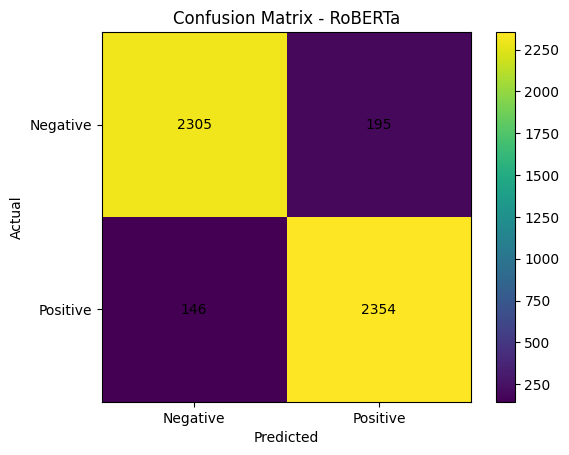

In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

roberta_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader_roberta:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = roberta_model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

# Metrics
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
conf_matrix = confusion_matrix(all_labels, all_preds)

print("\n--- RoBERTa Results ---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:\n", conf_matrix)

# Heatmap
plt.figure()
plt.imshow(conf_matrix)
plt.title("Confusion Matrix - RoBERTa")
plt.colorbar()

labels = ["Negative", "Positive"]
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

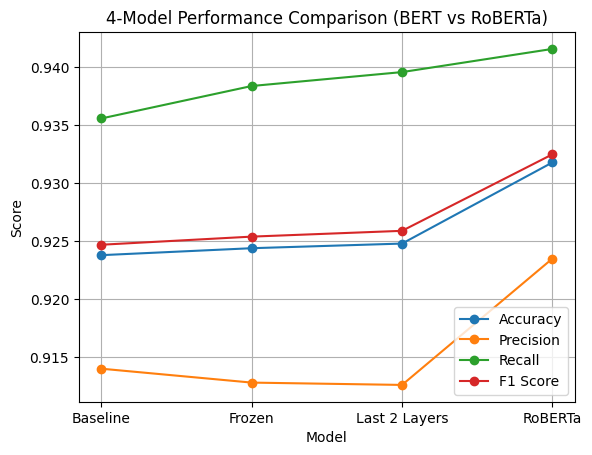

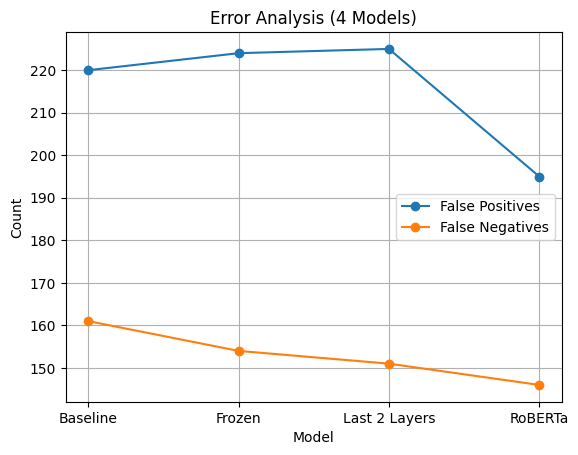

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Data (including RoBERTa)
results = {
    "Model": ["Baseline", "Frozen", "Last 2 Layers", "RoBERTa"],
    "Accuracy": [0.9238, 0.9244, 0.9248, 0.9318],
    "Precision": [0.9140, 0.9128, 0.9126, 0.9235],
    "Recall": [0.9356, 0.9384, 0.9396, 0.9416],
    "F1 Score": [0.9247, 0.9254, 0.9259, 0.9325],
    "False Positives": [220, 224, 225, 195],
    "False Negatives": [161, 154, 151, 146]
}

df = pd.DataFrame(results)

# --- Plot 1: Core Metrics ---
plt.figure()
for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    plt.plot(df["Model"], df[metric], marker='o', label=metric)

plt.title("4-Model Performance Comparison (BERT vs RoBERTa)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

# --- Plot 2: Error Comparison ---
plt.figure()
x = range(len(df["Model"]))

plt.plot(x, df["False Positives"], marker='o', label="False Positives")
plt.plot(x, df["False Negatives"], marker='o', label="False Negatives")

plt.xticks(x, df["Model"])
plt.title("Error Analysis (4 Models)")
plt.xlabel("Model")
plt.ylabel("Count")
plt.legend()
plt.grid()
plt.show()

# 🏁 Final Conclusion — BERT vs RoBERTa Experiments

## 🔍 Objective
The objective of this assignment was to explore BERT fine-tuning strategies and evaluate their impact on sentiment classification performance using the IMDB dataset. Additionally, a comparison with RoBERTa was performed as a bonus experiment.

---

## 🧪 Experiments Summary

### BERT Variants:
1. **Baseline (Full Fine-Tuning)**  
   - Entire model trained  
   - Strong performance, but computationally expensive  

2. **Frozen BERT**  
   - Only classifier trained  
   - Comparable performance with faster training  

3. **Last 2 Layers Fine-Tuned**  
   - Partial fine-tuning  
   - Best-performing BERT variant  

---

### RoBERTa:
- Fully fine-tuned on the same dataset  
- Achieved the best overall performance among all models  

---

## 📈 Final Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|------|--------|----------|--------|---------|
| Baseline (BERT) | 0.9238 | 0.9140 | 0.9356 | 0.9247 |
| Frozen BERT | 0.9244 | 0.9128 | 0.9384 | 0.9254 |
| Last 2 Layers (BERT) | 0.9248 | 0.9126 | 0.9396 | 0.9259 |
| **RoBERTa** | **0.9318** | **0.9235** | **0.9416** | **0.9325** |

---

## 🧠 Key Insights

- BERT already provides strong pre-trained representations, as even the frozen model performed competitively.
- Partial fine-tuning (last 2 layers) achieved the best trade-off between efficiency and performance among BERT variants.
- Full fine-tuning did not significantly outperform partial strategies, indicating diminishing returns.
- RoBERTa significantly outperformed all BERT-based approaches:
  - Higher F1 Score
  - Lower False Positives and False Negatives
  - Better overall generalization

---

## ⚖️ Model Comparison Summary

- **BERT (Full Fine-Tuning):** Maximum flexibility but not always necessary  
- **Frozen BERT:** Efficient and surprisingly strong  
- **Partial Fine-Tuning:** Best BERT strategy  
- **RoBERTa:** Best overall model due to improved pretraining strategy  

---

## ⚠️ Limitations

- All experiments were conducted using only **1 epoch**
- Longer training could lead to more pronounced differences
- Hyperparameter tuning was not extensively explored

---

## 🏆 Final Takeaway

> Smarter fine-tuning strategies can match or outperform full fine-tuning, and improved architectures like RoBERTa can provide significant gains over standard BERT.

---

## 🚀 Learning Outcome

Through this assignment, we:
- Understood transformer-based models (BERT, RoBERTa)
- Implemented fine-tuning pipelines from scratch
- Performed controlled experiments
- Analyzed model behavior using multiple evaluation metrics
- Compared architectures and training strategies effectively